Importing:

In [1]:
import  pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

Settting style and paths:

In [2]:
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("../data/processed") 

Loading data:

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
val = pd.read_csv(DATA_DIR / "val.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("dataset sizes:")
print(f"train: {len(train):,} rows")
print(f"val: {len(val):,} rows")
print(f"test: {len(test):,} rows")

dataset sizes:
train: 35,364 rows
val: 7,660 rows
test: 15,990 rows


These dataset proportions is adequate for my first version. I can always tweak them later

Basic Data Overview:

In [4]:
print("\n=== Train Set Info ===")
print(train.info())
print("\n=== Train Set Shape ===")
print(f"Rows: {train.shape[0]}, Columns: {train.shape[1]}")
print("\n=== First 5 Rows ===")
display(train.head())
print("\n=== Column Names ===")
print(train.columns.tolist())


=== Train Set Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35364 entries, 0 to 35363
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  35364 non-null  int64  
 1   best_of               35364 non-null  int64  
 2   player_ht             35320 non-null  float64
 3   player_age            35364 non-null  float64
 4   player_rank           35364 non-null  float64
 5   player_rank_points    35364 non-null  float64
 6   opponent_ht           35320 non-null  float64
 7   opponent_age          35364 non-null  float64
 8   opponent_rank         35364 non-null  float64
 9   opponent_rank_points  35364 non-null  float64
 10  label                 35364 non-null  int64  
 11  month                 35364 non-null  int64  
 12  rank_diff             35364 non-null  float64
 13  age_diff              35364 non-null  float64
 14  height_diff           35276 non-null  float64


,year,best_of,player_ht,player_age,player_rank,player_rank_points,opponent_ht,opponent_age,opponent_rank,opponent_rank_points,...,player_is_left,opponent_is_left,rounds_remaining,surface_Clay,surface_Grass,tourney_level_A,tourney_level_F,tourney_level_G,tourney_level_M,tourney_level_O
0,2013,3,180.0,29.4,60.0,754.0,196.0,23.6,43.0,937.0,...,0,0,5,False,False,True,False,False,False,False
1,2013,3,196.0,23.6,43.0,937.0,180.0,29.4,60.0,754.0,...,0,0,5,False,False,True,False,False,False,False
2,2013,3,185.0,25.1,48.0,872.0,183.0,31.0,57.0,769.0,...,0,0,5,False,False,True,False,False,False,False
3,2013,3,183.0,31.0,57.0,769.0,185.0,25.1,48.0,872.0,...,0,0,5,False,False,True,False,False,False,False
4,2013,3,188.0,25.0,32.0,1112.0,180.0,22.0,50.0,843.0,...,1,0,5,False,False,True,False,False,False,False



=== Column Names ===
['year', 'best_of', 'player_ht', 'player_age', 'player_rank', 'player_rank_points', 'opponent_ht', 'opponent_age', 'opponent_rank', 'opponent_rank_points', 'label', 'month', 'rank_diff', 'age_diff', 'height_diff', 'rank_points_diff', 'player_is_left', 'opponent_is_left', 'rounds_remaining', 'surface_Clay', 'surface_Grass', 'tourney_level_A', 'tourney_level_F', 'tourney_level_G', 'tourney_level_M', 'tourney_level_O']


This confirms that all of new columns are either in floats or integer, and columns are converted. We can now use this tabular data for the models

Target Variable Analysis:

In [5]:
print("\n=== Label Distribution ===")
print(train['label'].value_counts())
print(f"\nWin rate (label=1): {train['label'].mean():.2%}")


=== Label Distribution ===
label
1    17682
0    17682
Name: count, dtype: int64

Win rate (label=1): 50.00%


This 50/50 split is by design, not random. Since we encoded as winner = 1 and loser = 0, then winner = 0 and loser = 1, every match appears twice. Meaning, the win rate will always be 50%. This ensures the model sees the balanced win/loss examples. It's important to keep this in mind later on when we train the model, as the train dataset is doubled and avoid duplication

Missing Data Check:

In [6]:
print("\n=== Missing Data ===")
missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing data!")


=== Missing Data ===
             Missing Count  Missing %
height_diff             88   0.248841
player_ht               44   0.124420
opponent_ht             44   0.124420


There are 88 rows that don't have player height difference. However, we will let the model handle it as LightGBM/XGBoost will handle missing values natively and split on missing vaues.

TRAIN/VAL/TEST Comparison

In [7]:
print("\n=== Dataset Comparison ===")
total_size = len(train) + len(val) + len(test)
comparison = pd.DataFrame({
    'Train': [len(train), f"{len(train)/total_size:.1%}", train['label'].mean()],
    'Val': [len(val), f"{len(val)/total_size:.1%}", val['label'].mean()],
    'Test': [len(test), f"{len(test)/total_size:.1%}", test['label'].mean()]
}, index=['Size', 'Percentage', 'Win Rate'])
print(comparison)


=== Dataset Comparison ===
            Train    Val   Test
Size        35364   7660  15990
Percentage  59.9%  13.0%  27.1%
Win Rate      0.5    0.5    0.5


Although TEST is larger than VAL, this is fine for time-based splits. 0.5 across all datasets show consistent player view transformation. This validates proper data splitting based on time, and ready for model training.

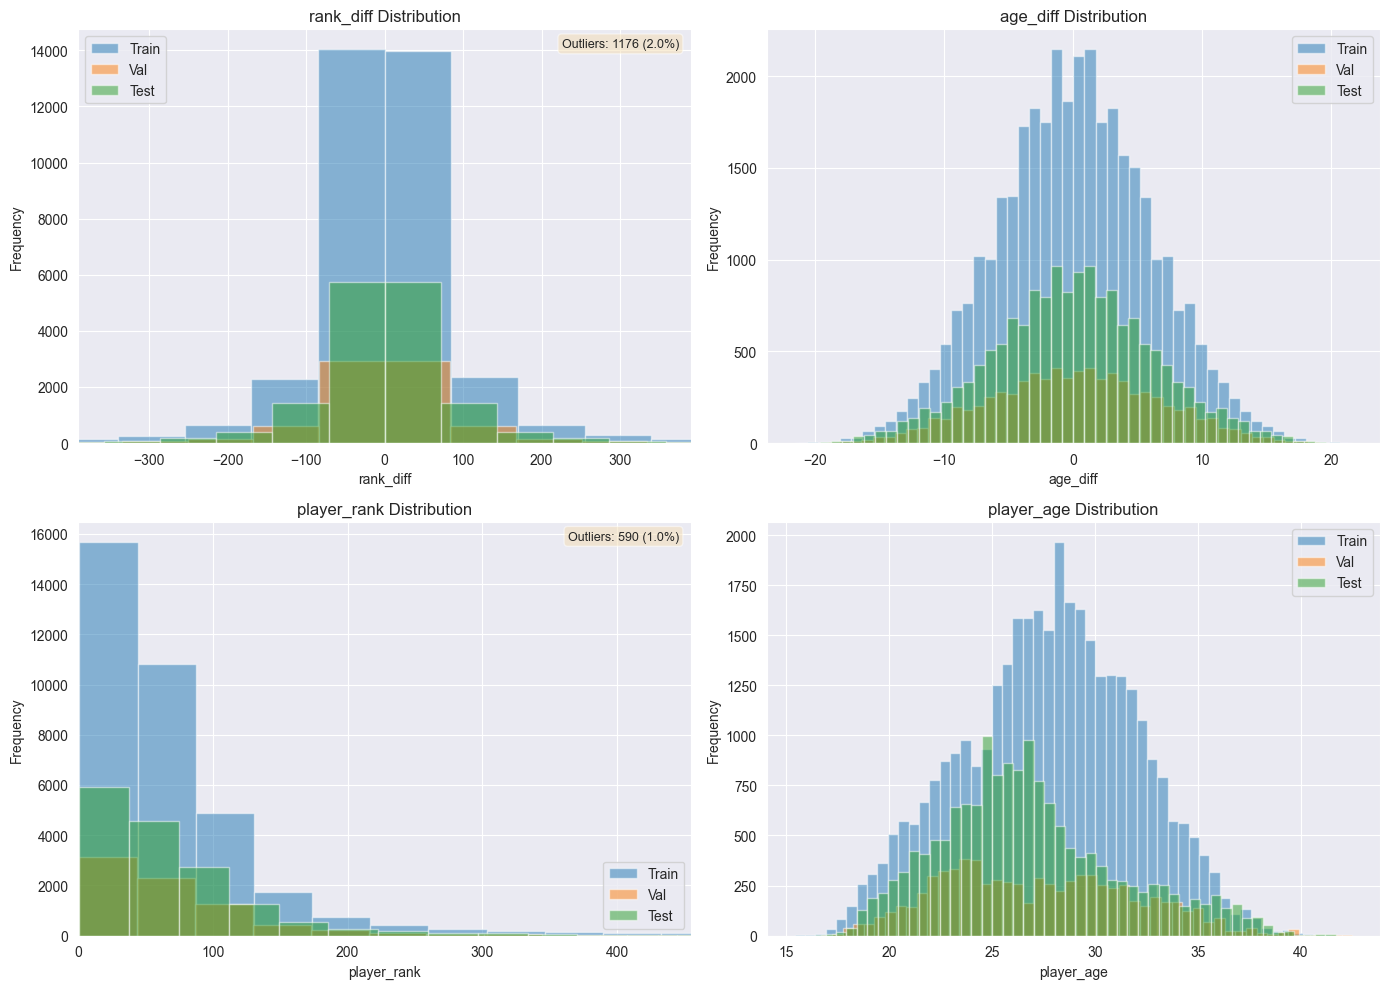

In [8]:
# Feature distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, feature in enumerate(['rank_diff', 'age_diff', 'player_rank', 'player_age']):
    ax = axes[i // 2, i % 2]
    
    # Plot all data
    train[feature].hist(alpha=0.5, label='Train', bins=50, ax=ax)
    val[feature].hist(alpha=0.5, label='Val', bins=50, ax=ax)
    test[feature].hist(alpha=0.5, label='Test', bins=50, ax=ax)
    
    ax.set_title(f'{feature} Distribution')
    ax.legend()
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    
    # Set x-axis limits to focus on main distribution
    if feature == 'rank_diff':
        combined_data = pd.concat([train[feature], val[feature], test[feature]])
        # Use 1st-99th percentile to show 98% of data
        lower, upper = combined_data.quantile([0.01, 0.99])
        ax.set_xlim(lower, upper)
        # Add annotation about outliers
        outlier_count = len(combined_data[(combined_data < lower) | (combined_data > upper)])
        ax.text(0.98, 0.98, f'Outliers: {outlier_count} ({outlier_count/len(combined_data)*100:.1f}%)',
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=9)
    elif feature == 'player_rank':
        combined_data = pd.concat([train[feature], val[feature], test[feature]])
        # Use 0-99th percentile since ranks start at 0
        upper = combined_data.quantile(0.99)
        ax.set_xlim(0, upper)
        outlier_count = len(combined_data[combined_data > upper])
        ax.text(0.98, 0.98, f'Outliers: {outlier_count} ({outlier_count/len(combined_data)*100:.1f}%)',
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=9)

plt.tight_layout()
plt.show()

As we are using tree-based models, they are usually robust to outliers. For the visualization purposes, we will set the x-axis limits to the 1st and 99th percentiles.

It is reasonable that the "player_rank" is right-skewed, as there are fewer players with higher rank score. In comparson to "rank_diff" distribution, right-skewed from individual player's rank would become normalized every high frequency of matches. The "player_age" distribution for TEST seems to be right skewed but "age_diff" distribution for all dataset seems to be normally distributed, we will do a further analysis.

In [9]:
# Age distribution comparison by split
print("\n=== Age Distribution by Split ===")
for split_name, split_data in [('Train', train), ('Val', val), ('Test', test)]:
    print(f"\n{split_name} (Years: {split_data['year'].min():.0f}-{split_data['year'].max():.0f}):")
    print(f"  Mean age: {split_data['player_age'].mean():.2f}")
    print(f"  Median age: {split_data['player_age'].median():.2f}")
    print(f"  Age 24-26 count: {((split_data['player_age'] >= 24) & (split_data['player_age'] <= 26)).sum()}")
    print(f"  Age 24-26 %: {((split_data['player_age'] >= 24) & (split_data['player_age'] <= 26)).sum() / len(split_data) * 100:.1f}%")

# Check if there's a temporal trend
print("\n=== Temporal Age Trend ===")
age_by_year = pd.concat([train, val, test]).groupby('year')['player_age'].agg(['mean', 'median', 'count'])
print(age_by_year)


=== Age Distribution by Split ===

Train (Years: 2013-2019):
  Mean age: 27.78
  Median age: 27.90
  Age 24-26 count: 4723
  Age 24-26 %: 13.4%

Val (Years: 2020-2021):
  Mean age: 27.25
  Median age: 27.10
  Age 24-26 count: 1229
  Age 24-26 %: 16.0%

Test (Years: 2022-2024):
  Mean age: 26.81
  Median age: 26.30
  Age 24-26 count: 3312
  Age 24-26 %: 20.7%

=== Temporal Age Trend ===
           mean  median  count
year                          
2013  27.463611   27.40   5018
2014  27.762521   27.70   4816
2015  27.839317   28.10   5036
2016  28.045990   28.30   5162
2017  28.021569   28.30   5100
2018  27.735669   28.05   5310
2019  27.597826   27.90   4922
2020  27.181188   27.20   2626
2021  27.280473   26.90   5034
2022  26.987009   26.10   5242
2023  26.798460   26.30   5324
2024  26.642773   26.40   5424


The result clearly implies overall trend of newer generation's mean age shifting younger. The distribution shifted of age 24-26 group increase from 13.4% (trian) to 20.7% (test). Although this is not a critical issue as there are other factors in play, this might be more detrimental later on if age proves to be the leading factor in the odds.

Time-based split also confirmed: Train (2013-2019) < Val (2020-2021) < Test (2022-2024)

Data Leakage Check:

In [10]:
print("\n=== Data Leakage Check ===")
identity_columns = [
    "player_id",
    "player_name", 
    "player_ioc",
    "opponent_id",
    "opponent_name",
    "opponent_ioc",
    "tourney_id",
    "tourney_name"
]

print("Checking for identity columns in processed data:")
leakage_found = False
for col in identity_columns:
    if col in train.columns:
        print(f" LEAKAGE: {col} is still present!")
        leakage_found = True
    else:
        print(f" {col} correctly removed")

if not leakage_found:
    print("\nNo data leakage detected. All identity columns have been removed")
else:
    print("\nIdentity columns found. These should be removed to prevent overfitting.")


=== Data Leakage Check ===
Checking for identity columns in processed data:
 player_id correctly removed
 player_name correctly removed
 player_ioc correctly removed
 opponent_id correctly removed
 opponent_name correctly removed
 opponent_ioc correctly removed
 tourney_id correctly removed
 tourney_name correctly removed

No data leakage detected. All identity columns have been removed


This confirms that there are no data leakage present in the new dataset

Key Insights & Summary

In [11]:
print("\n=== Key Insights ===")
print(f"1. Dataset is {'balanced' if 0.45 < train['label'].mean() < 0.55 else 'imbalanced'} (50/50 split by design)")
print(f"2. Rank difference range: {train['rank_diff'].min():.0f} to {train['rank_diff'].max():.0f}")
print(f"3. Age difference range: {train['age_diff'].min():.1f} to {train['age_diff'].max():.1f}")
print(f"4. Missing data: {train.isnull().sum().sum()} total missing values (all height-related, with 44 rows per column + 88 rows for difference)")
print(f"5. Histogram shows that rank_diff and age_diff are normally distributed, while player_rank and player_age are right skewed")
print(f"6. Age distribution comparison by split shows that the distribution is right skewed, but the mean and median age are close, indicating that the data is generally consistent across splits")
print(f"7. Temporal age trend analysis shows that the mean age is getting younger over time, which might be a concern for model performance if age is a critical factor")
print(f"8. Data leakage check shows identity columns are removed")



=== Key Insights ===
1. Dataset is balanced (50/50 split by design)
2. Rank difference range: -2125 to 2125
3. Age difference range: -21.5 to 21.5
4. Missing data: 176 total missing values (all height-related, with 44 rows per column + 88 rows for difference)
5. Histogram shows that rank_diff and age_diff are normally distributed, while player_rank and player_age are right skewed
6. Age distribution comparison by split shows that the distribution is right skewed, but the mean and median age are close, indicating that the data is generally consistent across splits
7. Temporal age trend analysis shows that the mean age is getting younger over time, which might be a concern for model performance if age is a critical factor
8. Data leakage check shows identity columns are removed
